<a href="https://colab.research.google.com/github/Schr0dinger0/university_Computer_Math/blob/main/09.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F%20%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2%20%D0%B8%20%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F%20%D0%A4%D1%83%D1%80%D1%8C%D0%B5/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D0%B8_%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F_%D0%A4%D1%83%D1%80%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Генерация сигналов и преобразования Фурье**

# Блок №1. Базовый уровень

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift
from scipy.signal import spectrogram
from scipy import signal
import random
from scipy.io import wavfile

def random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



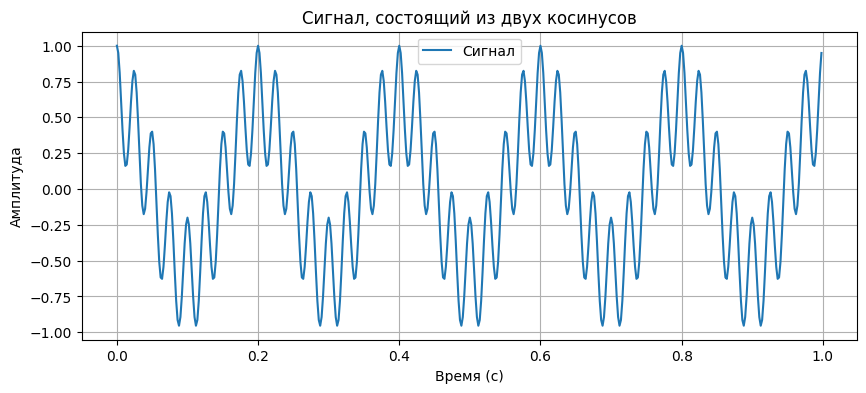

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500.0      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

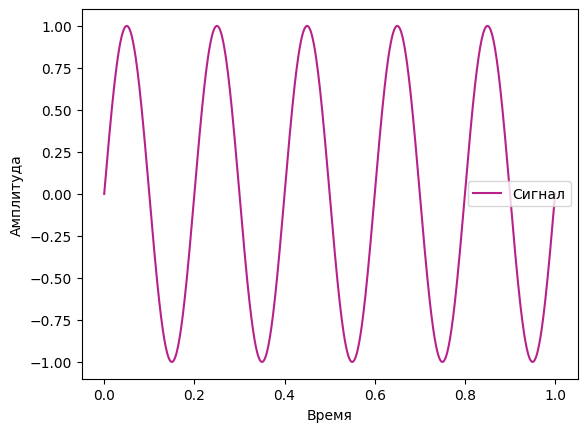

In [13]:
def sin_signal(a=1, fs=1000, fi=0, f=5):
  t = np.linspace(0, 1, fs)
  signal = a * np.sin(2 * np.pi * f * t + fi)
  return t, signal

t, signal1 = sin_signal()
plt.plot(t, signal1, label='Сигнал', color=random_color())
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.legend()
plt.show()

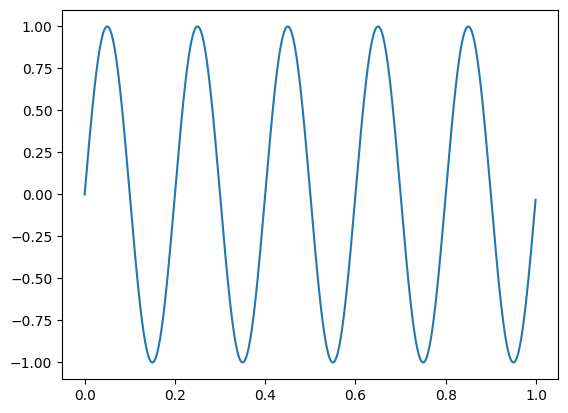

In [ ]:
# Пример

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

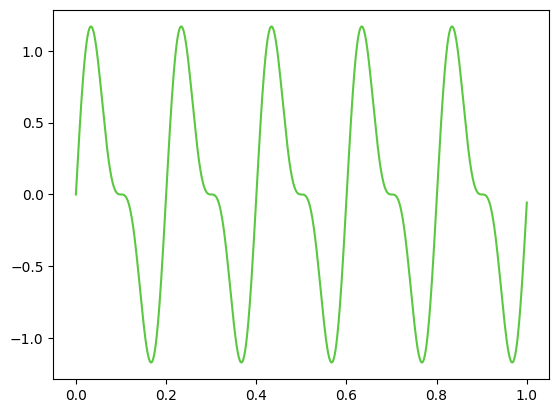

In [15]:
def sum_of_sin(fs=1000.0, a1=0.9, a2=0.45, f1=5.0, f2=10.0, fi1=0.0, fi2=0.0):
  t = np.arange(0, 1, 1/fs)
  signal = a1 * np.sin(2 * np.pi * f1 * t + fi1) + a2 * np.sin(2 * np.pi * f2 * t + fi2)
  return signal

signal2 = sum_of_sin()
plt.plot(t, signal2, label='Сигнал', color=random_color())
plt.show()

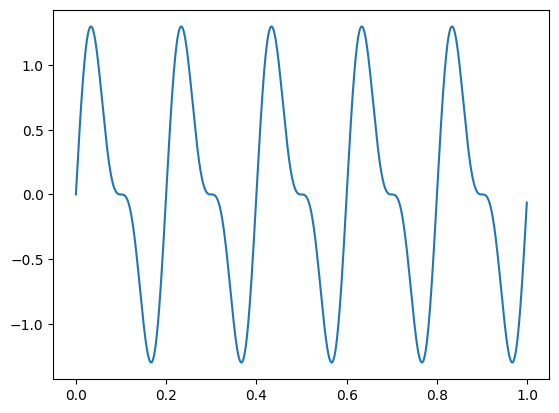

In [ ]:
# Пример

3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

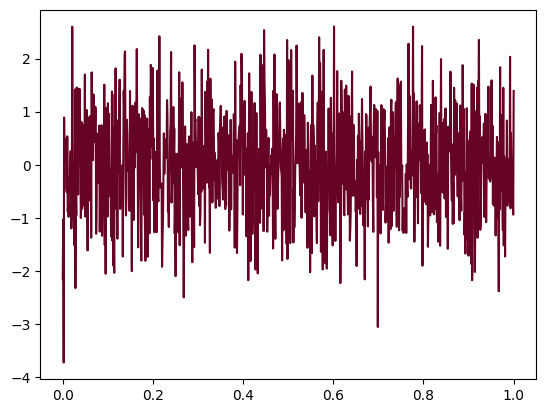

In [17]:
def noise_signal(fs=1000, a=1):
  t = np.linspace(0, 1, fs, endpoint=False)
  noise = a * np.random.randn(fs)
  return noise

noise = noise_signal()
plt.plot(t, noise, color=random_color())
plt.show()

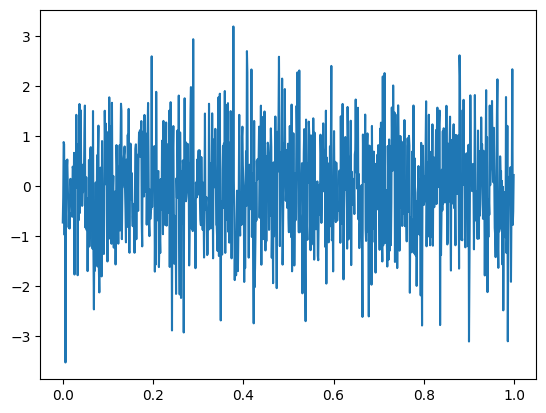

In [ ]:
# Пример

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

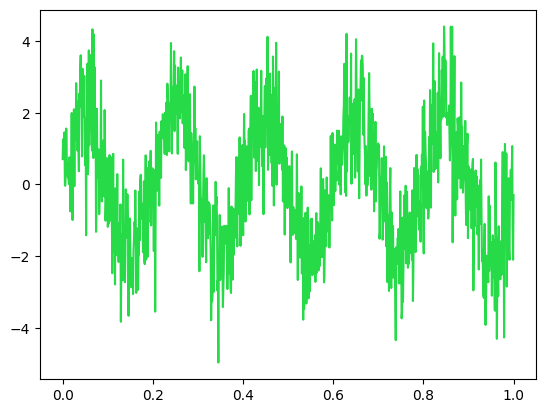

In [20]:
def sin_and_noise(fs=1000, a=2, f=5, fi=0):
  t = np.linspace(0, 1, fs)
  sin_signal = a * np.sin(2 * np.pi * f * t + fi)
  noise = np.random.randn(fs)
  signal = sin_signal + noise
  return signal

signal4 = sin_and_noise()
plt.plot(t, signal4, color=random_color())
plt.show()

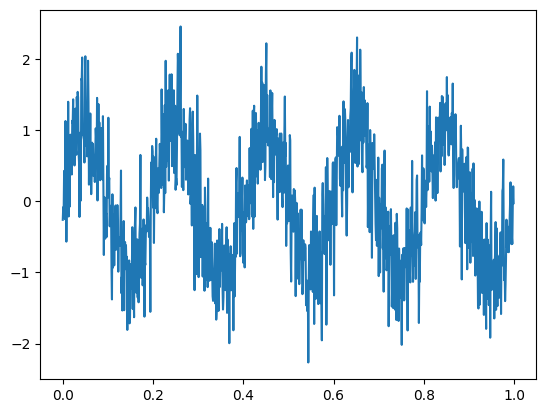

In [ ]:
# Пример

## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


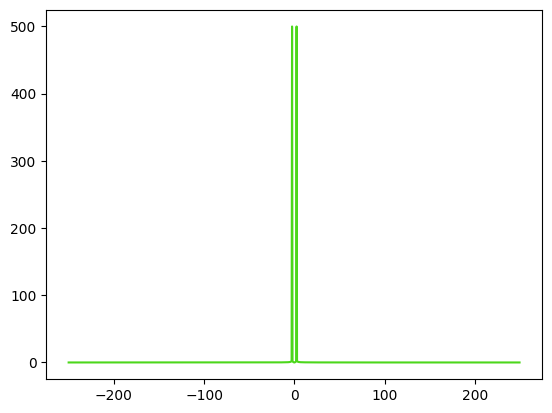

In [23]:
n = signal1.size
fft_result = fft(signal1)
frequencies = fftfreq(n, 1/fs)
fft_shifted = fftshift(fft_result)
frequencies_shifted = fftshift(frequencies)
plt.plot(frequencies_shifted, np.abs(fft_shifted), color=random_color())
plt.show()

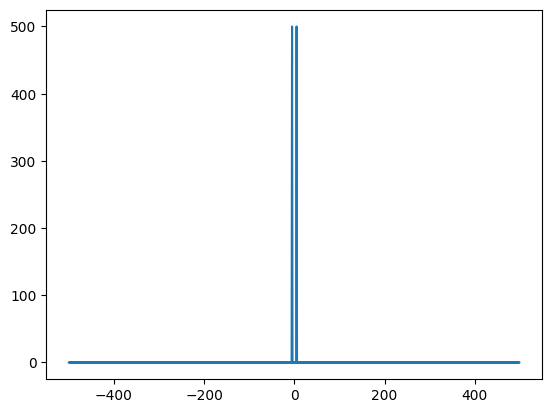

In [ ]:
# Пример

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


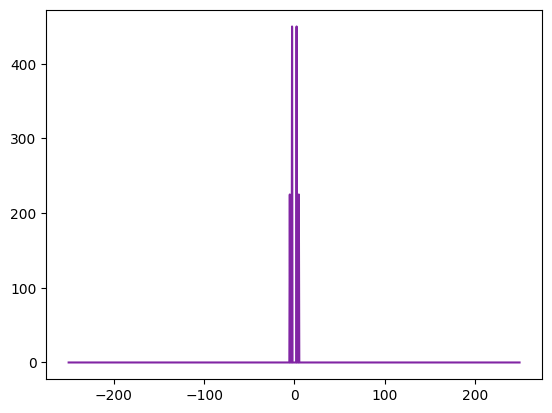

In [26]:
n = signal2.size
fft_result = fft(signal2)
frequencies = fftfreq(n, 1/fs)
fft_shifted = fftshift(fft_result)
frequencies_shifted = fftshift(frequencies)
plt.plot(frequencies_shifted, np.abs(fft_shifted), color=random_color())
plt.show()

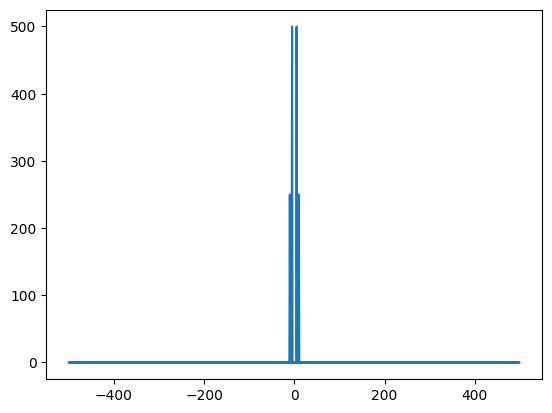

In [ ]:
# Пример

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


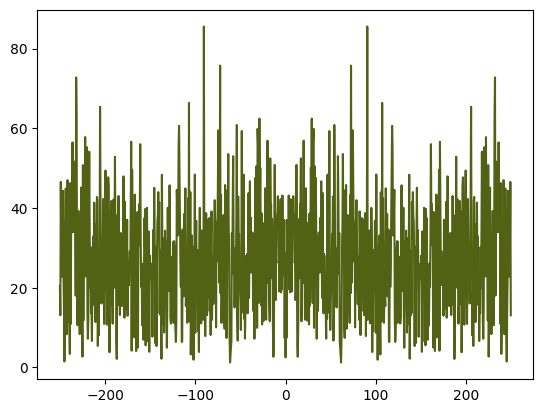

In [30]:
n = noise.size
fft_result = fft(noise)
frequencies = fftfreq(n, 1/fs)
fft_shifted = fftshift(fft_result)
frequencies_shifted = fftshift(frequencies)
plt.plot(frequencies_shifted, np.abs(fft_shifted), color=random_color())
plt.show()

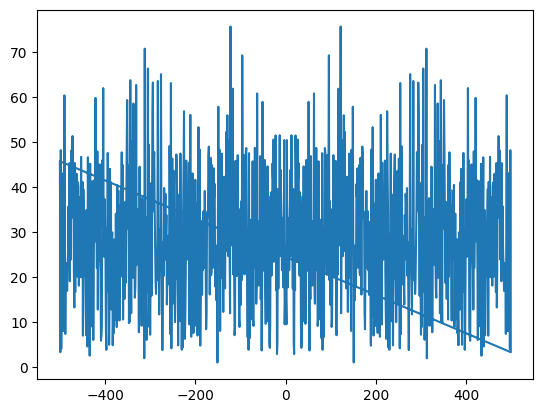

In [ ]:
# Пример

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

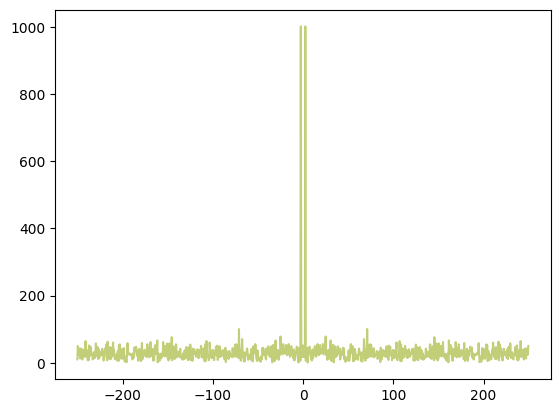

In [32]:
n = signal4.size
fft_result = fft(signal4)
frequencies = fftfreq(n, 1/fs)
fft_shifted = fftshift(fft_result)
frequencies_shifted = fftshift(frequencies)
plt.plot(frequencies_shifted, np.abs(fft_shifted), color=random_color())
plt.show()

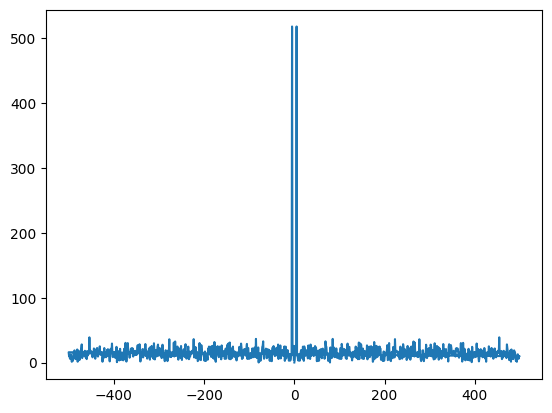

In [ ]:
# Пример

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

In [33]:
def signal_filter(signal, cutoff, fs=1000.0):
  n = signal.size
  fft_result = fft(signal)
  frequencies = fftfreq(n, 1/fs)
  fft_result[np.abs(frequencies) > cutoff] = 0
  filtered_signal = ifft(fft_result)
  return np.real(filtered_signal)

In [ ]:
# Пример

2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

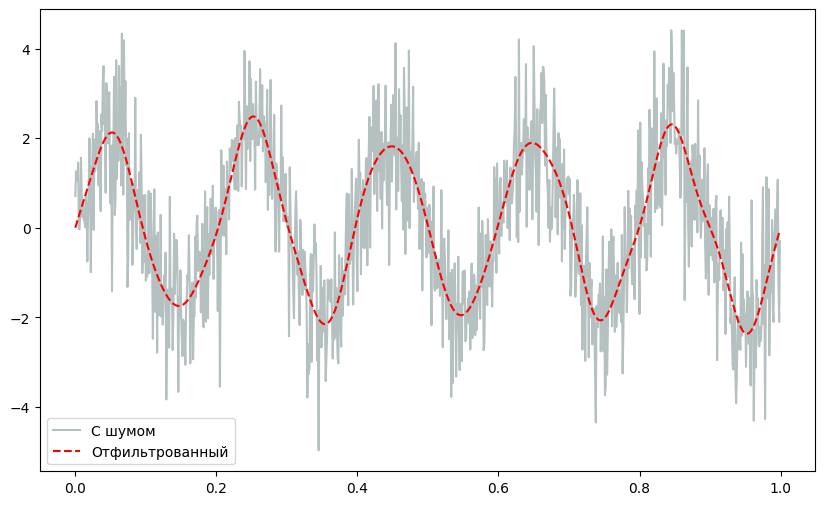

In [35]:
cutoff = 15
t = np.arange(0, 1, 1/1000.0)
filtered_signal = signal_filter(signal4, cutoff, 1000.0)

plt.figure(figsize=(10,6))
plt.plot(t, signal4, label='С шумом', color=random_color())
plt.plot(t, filtered_signal, '--', color='red', label='Отфильтрованный')
plt.legend()
plt.show()

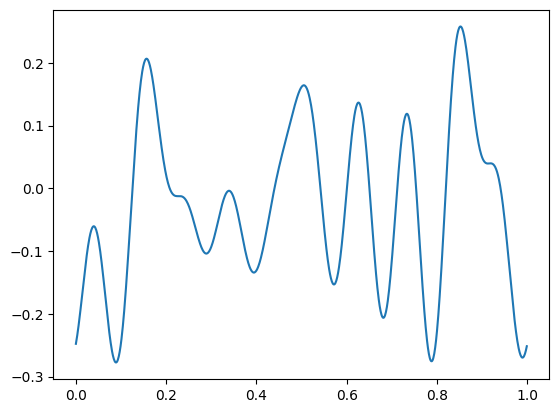

In [ ]:
# Пример

## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


In [40]:
def signal_spectrogram(signal, fs):
  f, t, Sxx = spectrogram(signal, fs)
  plt.pcolormesh(t, f, 10 * np.log(Sxx), shading='gouraud')
  plt.colorbar()
  plt.show()

2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

Синусоидальный сигнал


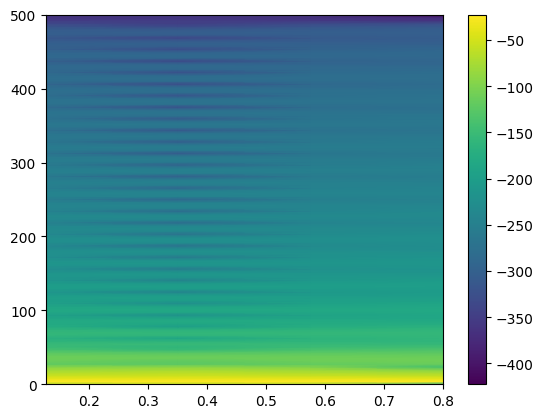

Сумма синусоид


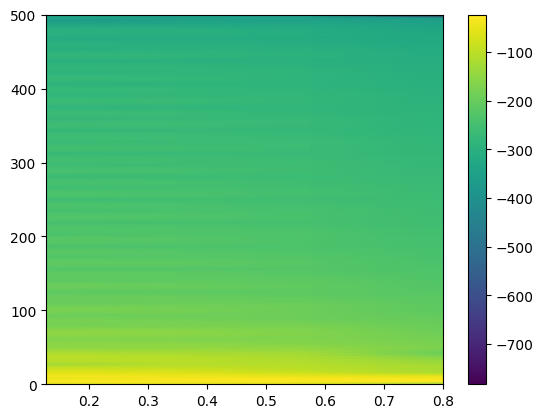

Шумовой сигнал


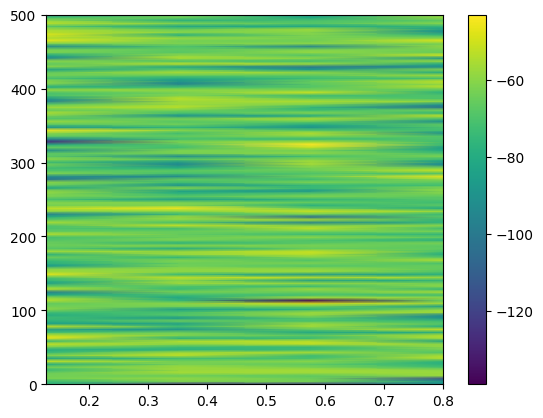

Синусоида плюс шум


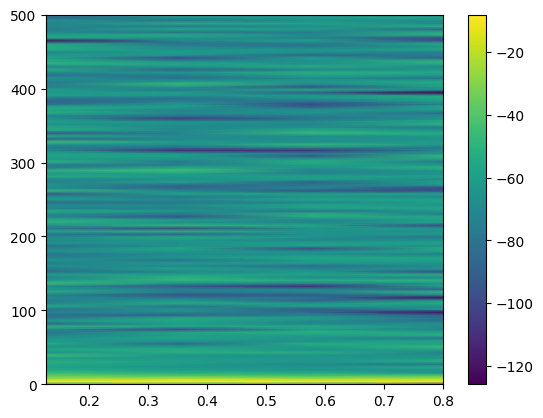

In [41]:
print('Синусоидальный сигнал')
signal_spectrogram(signal1, 1000.0)
print('Сумма синусоид')
signal_spectrogram(signal2, 1000.0)
print('Шумовой сигнал')
signal_spectrogram(noise, 1000.0)
print('Синусоида плюс шум')
signal_spectrogram(signal4, 1000.0)

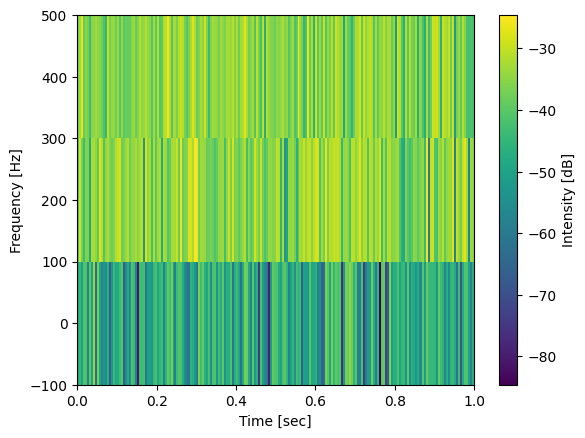

In [ ]:
# Пример

# Блок №2. Повышенный уровень

## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [62]:
samplerate, data = wavfile.read('./aboba.wav')

2. Визуализируйте временную форму звукового сигнала.

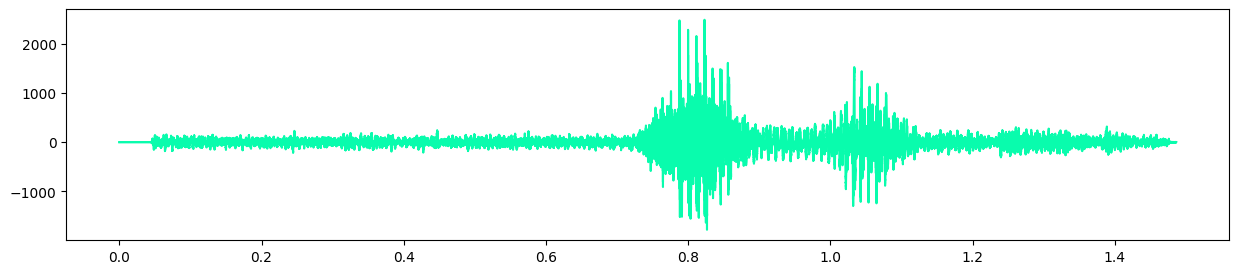

In [54]:
l = data.shape[0] / samplerate
t = np.linspace(0., l, data.shape[0])
plt.figure(figsize=(15, 3))
plt.plot(t, data, color=random_color())
plt.show()

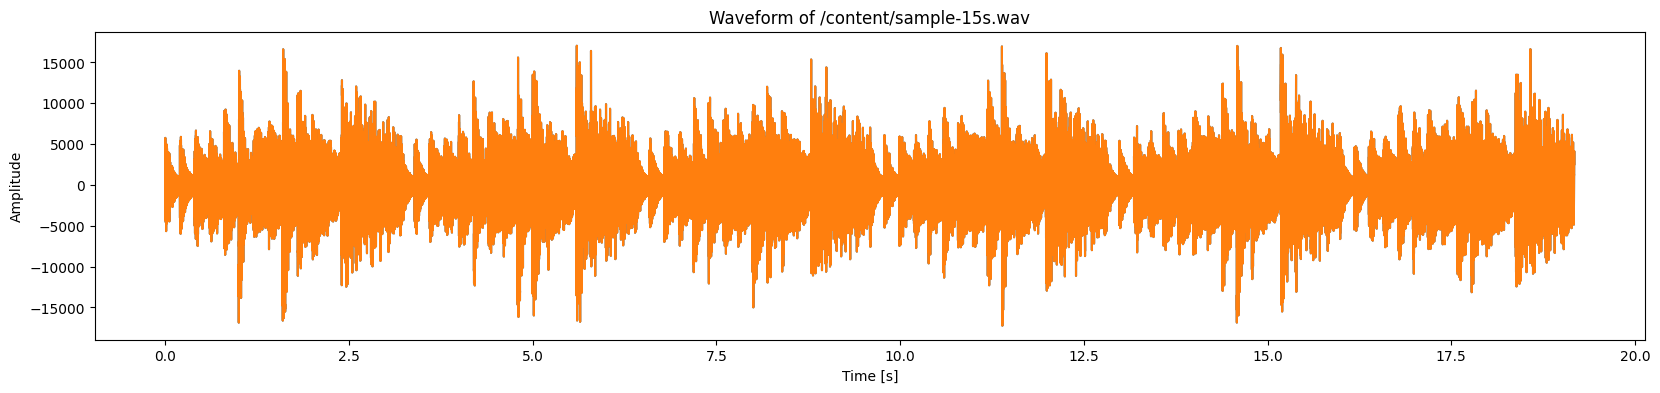

In [ ]:
# Пример

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

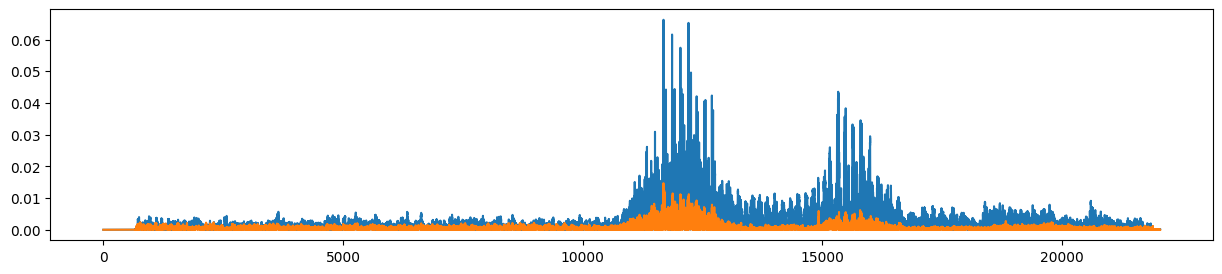

In [56]:
n = data.size
fft_result = fft(data)
frequencies = fftfreq(n, 1/samplerate)
plt.figure(figsize=(15, 3))
plt.plot(frequencies[:n // 2], (2/n) * np.abs(fft_result)[:n // 2])
plt.show()

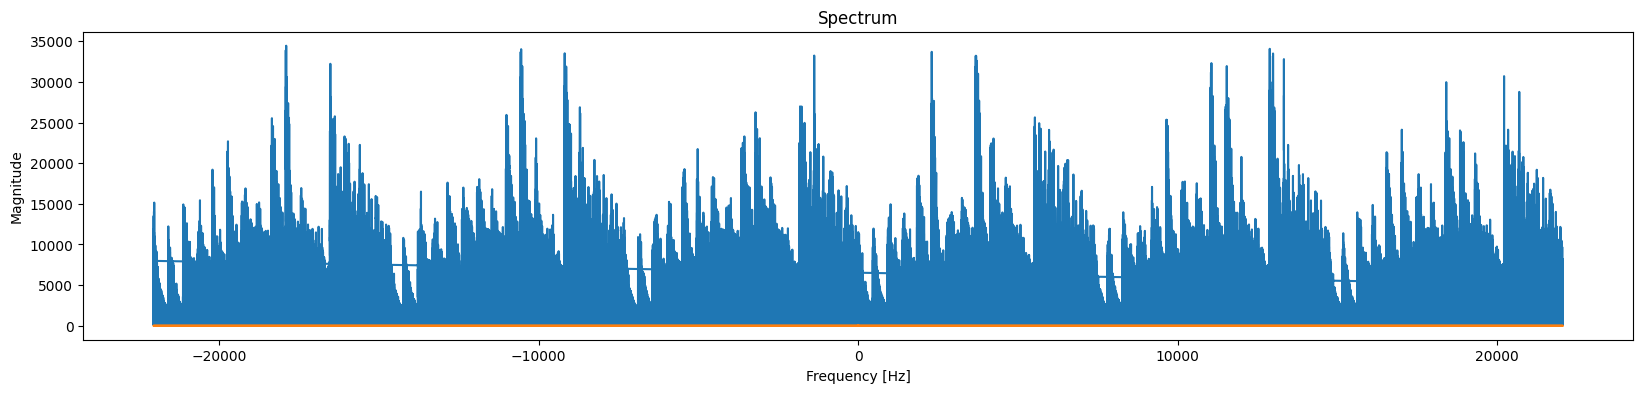

In [ ]:
# Пример

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [106]:
def signal_filter(signal, cutoff, fs=1000.0):
  n = signal.shape[0]
  fft_result = fft(signal)
  frequencies = fftfreq(n, 1/fs)
  fft_result[np.abs(frequencies) < cutoff] = 0
  filtered_signal = ifft(fft_result)
  return np.real(filtered_signal)

2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

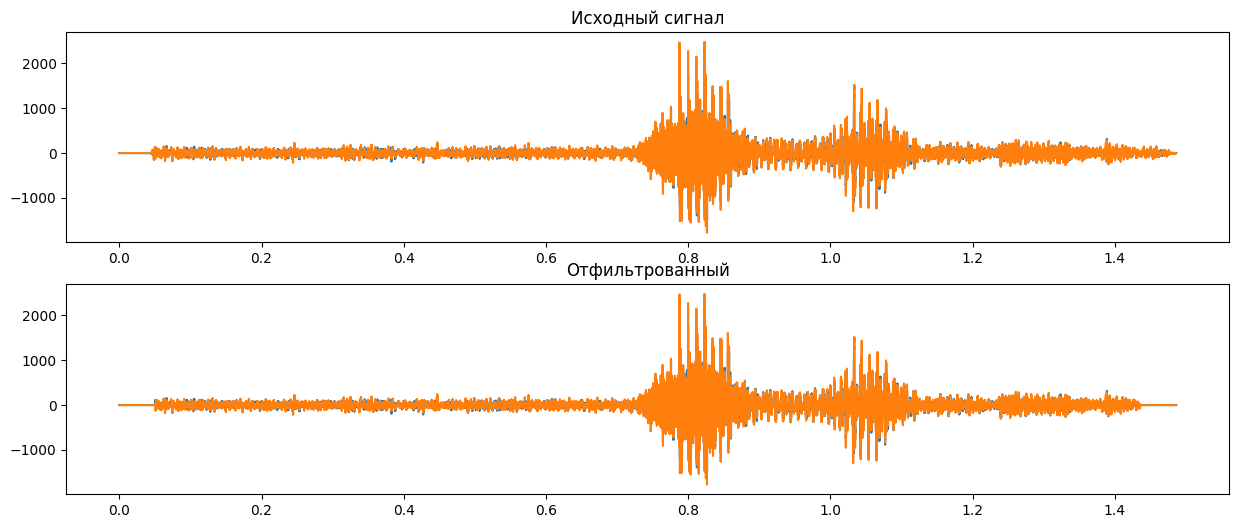

In [111]:
cutoff = 1500.0
n = data.shape[0]
t = np.linspace(0, n/samplerate, num=n)
filtered_signal = signal_filter(data, cutoff, samplerate)

fig, axes = plt.subplots(2, 1, figsize=(15, 6))
axes[0].plot(t, data)
axes[0].set_title('Исходный сигнал')
axes[1].plot(t, filtered_signal)
axes[1].set_title('Отфильтрованный')
plt.show()

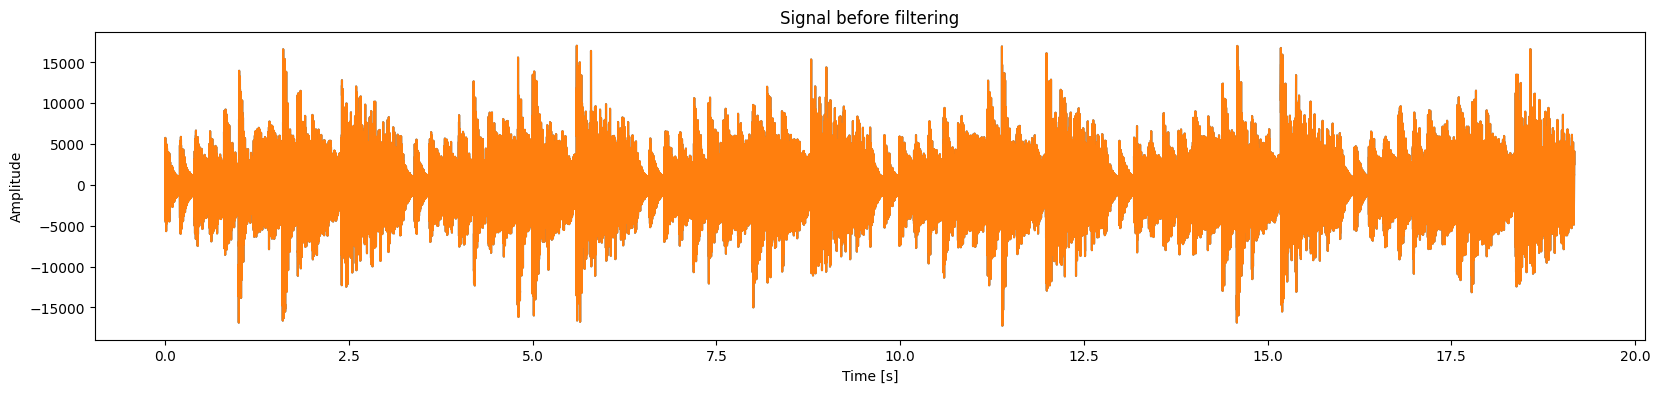

In [ ]:
# Визуализация сигнала до фильтрации

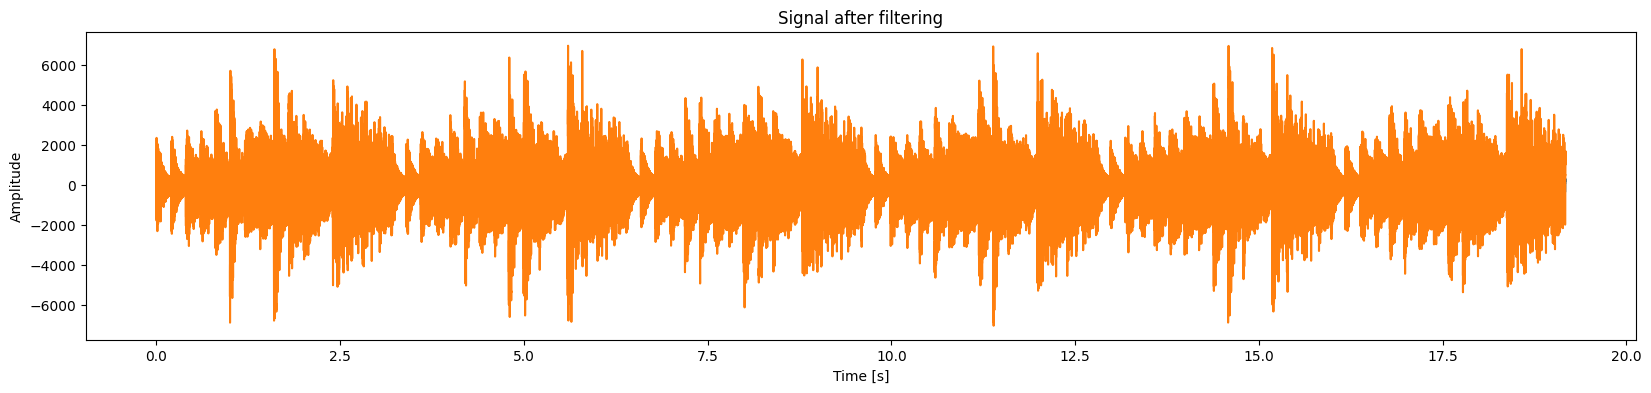

In [ ]:
# Визуализация сигнала после фильтрации

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [112]:
n = len(data)
cutoff = 1000
fft_result = fft(data)
frequencies = fftfreq(n, 1/samplerate)
fft_filtered = fft_result
fft_filtered[np.abs(frequencies) > cutoff] = 0
filtered_signal = np.real(ifft(fft_filtered))
new_signal = filtered_signal.astype(data.dtype)

2. Сохраните полученный сигнал в новый звуковой файл.

In [113]:
output = 'test_filtered.wav'
wavfile.write(output, samplerate, new_signal)